In [41]:
from sklearn.datasets import load_wine
import torch
wine = load_wine(as_frame=True)
X = wine.data
# are we missing a step here?
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)


In [42]:
X.shape

(178, 13)

In [43]:


class wine_auto_encoder(torch.nn.Module):
    def __init__(self, input_dim, output_dim=3):
        super().__init__()
        self.fc1 = torch.nn.Linear(input_dim, 8)
        self.fc2 = torch.nn.Linear(8, output_dim)
        self.fc3 = torch.nn.Linear(output_dim, 8)
        self.fc4 = torch.nn.Linear(8, input_dim)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        # x = self.fc1(x)
        # x = self.relu(x)
        # x = self.fc2(x)
        # x = self.relu(x)
        # x = self.fc3(x)
        # x = self.relu(x)
        # x = self.fc4(x)
        x = self.encode(x)
        x = self.decode(x)
        return x

    def encode(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

    def decode(self, x):
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x

model = wine_auto_encoder(input_dim=X.shape[1], output_dim=2)
# reconstruction loss
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
losses = []
for epoch in range(10000):
    optimizer.zero_grad()
    
    X_reconstructed = model(X_tensor)
    loss = criterion(X_reconstructed, X_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

   

Epoch 0, Loss: 1.2467056512832642
Epoch 100, Loss: 0.5554201602935791
Epoch 200, Loss: 0.40836501121520996
Epoch 300, Loss: 0.3733507990837097
Epoch 400, Loss: 0.353706955909729
Epoch 500, Loss: 0.34625205397605896
Epoch 600, Loss: 0.33971109986305237
Epoch 700, Loss: 0.3317527174949646
Epoch 800, Loss: 0.32572734355926514
Epoch 900, Loss: 0.3213156461715698
Epoch 1000, Loss: 0.3174554407596588
Epoch 1100, Loss: 0.3143802881240845
Epoch 1200, Loss: 0.31148573756217957
Epoch 1300, Loss: 0.30934005975723267
Epoch 1400, Loss: 0.30524957180023193
Epoch 1500, Loss: 0.30366984009742737
Epoch 1600, Loss: 0.3027113378047943
Epoch 1700, Loss: 0.3016410768032074
Epoch 1800, Loss: 0.3008928596973419
Epoch 1900, Loss: 0.3001251220703125
Epoch 2000, Loss: 0.29934796690940857
Epoch 2100, Loss: 0.2988360822200775
Epoch 2200, Loss: 0.29828983545303345
Epoch 2300, Loss: 0.2979467213153839
Epoch 2400, Loss: 0.2975628077983856
Epoch 2500, Loss: 0.29734039306640625
Epoch 2600, Loss: 0.2969740033149719
Epo

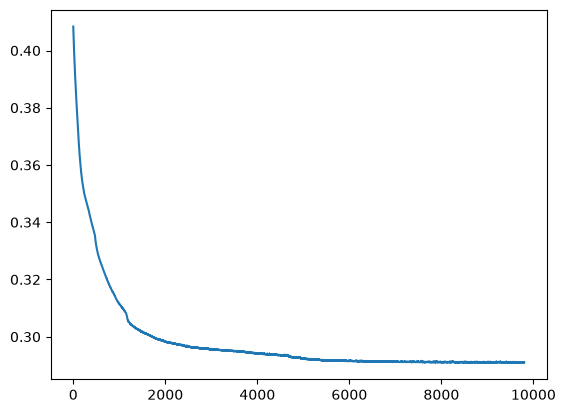

In [44]:
import matplotlib.pyplot as plt
plt.plot(losses[200:])

In [45]:
# model.eval()
# print(model(torch.tensor(X[0:1].values, dtype=torch.float32)))
# print(model.encode(torch.tensor(X[0:1].values, dtype=torch.float32)))
# print(X[0:1])

In [46]:
import pandas as pd
original = X_scaled[0]

reconstructed = model.decode(
    model.encode(
        torch.tensor(X_scaled[0:1], dtype=torch.float32)
    )
).detach().numpy()[0]

comparison = pd.DataFrame({
    "Original": original,
    "Reconstructed": reconstructed
}, index=X.columns)

comparison

,Original,Reconstructed
alcohol,1.518613,1.194598
malic_acid,-0.562250,-0.506341
ash,0.232053,0.465483
alcalinity_of_ash,-1.169593,-0.817324
magnesium,1.913905,0.688497
total_phenols,0.808997,1.033890
flavanoids,1.034819,1.084278
nonflavanoid_phenols,-0.659563,-0.479168
proanthocyanins,1.224884,0.527153
color_intensity,0.251717,0.458410


In [47]:
# rescale to original scale
original = X.iloc[0]
reconstructed = scaler.inverse_transform(reconstructed.reshape(1, -1)).flatten()

comparison = pd.DataFrame({
    "Original": original,
    "Reconstructed": reconstructed
}, index=X.columns)

comparison


,Original,Reconstructed
alcohol,14.23,13.967696
malic_acid,1.71,1.772282
ash,2.43,2.493860
alcalinity_of_ash,15.60,16.773117
magnesium,127.00,109.547363
total_phenols,2.80,2.940354
flavanoids,3.06,3.109264
nonflavanoid_phenols,0.28,0.302388
proanthocyanins,2.29,1.891771
color_intensity,5.64,6.117826


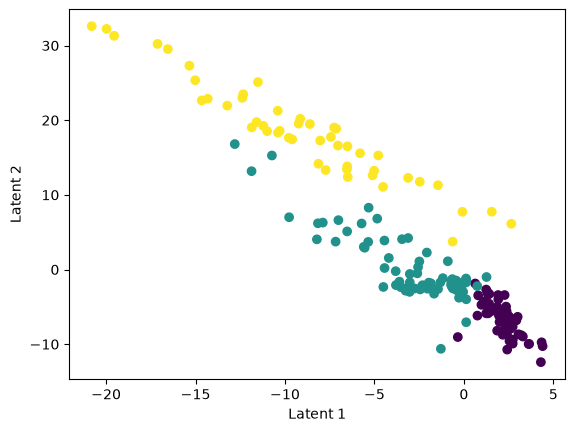

In [48]:
with torch.no_grad():
    Z = model.encode(X_tensor).numpy()

plt.scatter(Z[:, 0], Z[:, 1], c=wine.target)
plt.xlabel("Latent 1")
plt.ylabel("Latent 2")
plt.show()